# Plant Disease Classification

We use:

1. Image preprocessing
2. Simple feature extraction
3. Train/test split
4. K-Nearest Neighbors
5. Logistic Regression
6. Support Vector Machines
7. A simple neural network using `MLPClassifier`
8. Basic CNN
9. Accuracy, precision, recall, F1-score, and confusion matrices

The goal is to ML models on a plant disease image classification task.


## 1. Install and import libraries

kagglehub is only used to download the PlantVillage dataset. The machine learning models come from scikit-learn.


In [ ]:
#see README 'Dataset Setup'.


In [2]:
!pip install -q kagglehub scikit-learn matplotlib pillow

import random
from pathlib import Path

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 2. Download PlantVillage dataset

PlantVillage is used here as the labeled image dataset.

In [3]:
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print(f"Downloaded to: {path}")

# Locate the color image folder
data_dir = None
for root, dirs, files in os.walk(path):
    if "color" in dirs:
        data_dir = Path(root) / "color"
        break

if data_dir is None:
    raise FileNotFoundError("Could not find the color folder in the dataset.")

print(f"Data directory: {data_dir}")


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Downloaded to: /kaggle/input/plantvillage-dataset
Data directory: /kaggle/input/plantvillage-dataset/plantvillage dataset/color


## 3. Select a smaller set of classes

In [4]:
all_class_dirs = []

for d in data_dir.iterdir():
    if d.is_dir():
        all_class_dirs.append(d)

all_class_dirs = sorted(all_class_dirs)

all_class_names = []

for d in all_class_dirs:
    all_class_names.append(d.name)

print(f"Total available classes: {len(all_class_names)}")

for name in all_class_names[:10]:
    print(name)


class_choices = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___healthy",
]

selected_classes = []

for c in class_choices:
    if c in all_class_names:
        selected_classes.append(c)

if len(selected_classes) == 0:
    selected_classes = all_class_names[:5]

print("\nSelected classes:")

for c in selected_classes:
    print(c)

Total available classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight

Selected classes:
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___healthy


## 4. Convert images into simple feature vectors

So we convert each image into numerical features. This notebook uses two simple feature types:

1. Flattened resized pixels: resize image to `32 x 32`, then turn it into one long vector
2. Color features: average red, green, and blue values

This keeps the project connected to class topics because the models are learning from vectors, just like examples from lectures.


In [5]:
IMG_SIZE = 32
MAX_IMAGES_PER_CLASS = 400

def image_to_features(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    arr = np.array(img) / 255.0

    # Feature 1: flattened pixels
    flattened_pixels = arr.flatten()

    # Feature 2: average RGB values
    mean_rgb = arr.mean(axis=(0, 1))

    # Combine both into one vector
    features = np.concatenate([flattened_pixels, mean_rgb])

    return features


## 5. Load images and labels

This cell loops through the selected class folders, extracts features, and creates `X` and `y`.

- `X` contains the image feature vectors
- `y` contains the class labels


In [6]:
X = [] # feature vectors
y = [] # labels
image_paths = []
label_names = []

# Loop though each selected class
for label_index in range(len(selected_classes)):
    class_name = selected_classes[label_index]
    class_folder = data_dir / class_name

    # Collect all images with different extensions
    files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        files.extend(list(class_folder.glob(ext)))

    random.shuffle(files) # Remove bias
    files = files[:MAX_IMAGES_PER_CLASS]

    print(f"{class_name}: using {len(files)} images")

    # Process each image
    for image_path in files:
        try:
            features = image_to_features(image_path) # Convert to feature vector
            X.append(features)
            y.append(label_index)
            image_paths.append(image_path)
        except Exception as e:
            print(f"Skipping {image_path}: {e}")

    label_names.append(class_name)

X = np.array(X)
y = np.array(y)

print("\nFinal dataset shape:")
print("X:", X.shape)
print("y:", y.shape)


Tomato___Bacterial_spot: using 400 images
Tomato___Early_blight: using 400 images
Tomato___Late_blight: using 400 images
Tomato___Leaf_Mold: using 400 images
Tomato___healthy: using 400 images

Final dataset shape:
X: (2000, 3075)
y: (2000,)


## 6. Show sample images

Not part of training, but it helps show that the data loaded correctly.


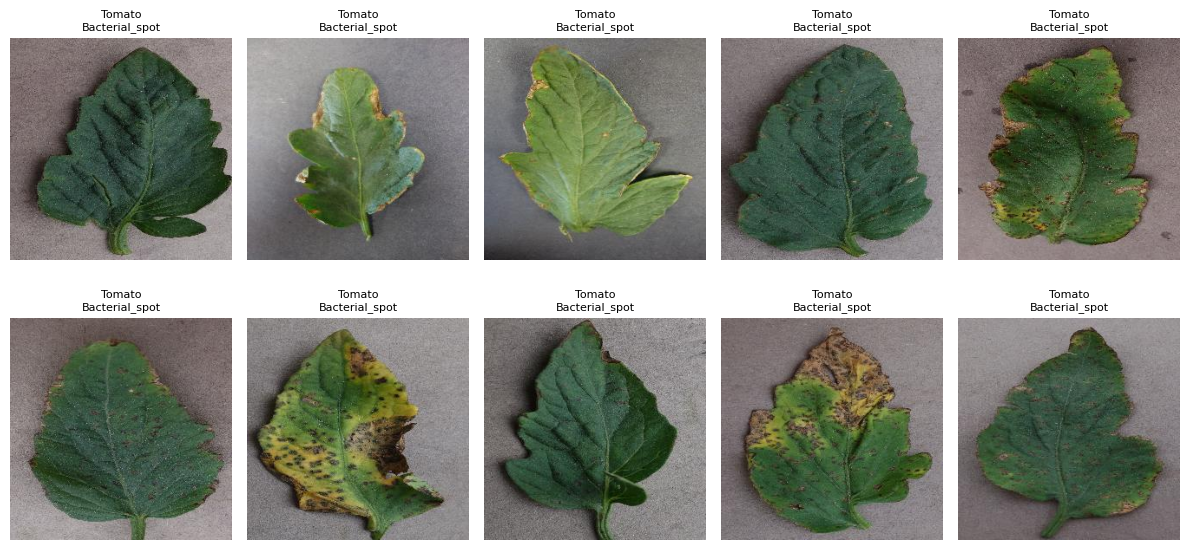

In [7]:
plt.figure(figsize=(12, 6))

for i in range(min(10, len(image_paths))):
    plt.subplot(2, 5, i + 1)
    img = Image.open(image_paths[i]).convert("RGB")
    plt.imshow(img)
    plt.title(label_names[y[i]].replace("___", "\n"), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Train/test split and feature scaling

Many ML models work better when features are scaled.

We fit the scaler only on the training data, then transform both training and testing data. This avoids leaking information from the test set.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Testing set:", X_test_scaled.shape)


Training set: (1500, 3075)
Testing set: (500, 3075)


## 8. Train models

These models connect directly to the class topics:

- K-Nearest Neighbors: non-parametric model
- Logistic Regression: parametric model
- SVM: margin-based classifier
- MLPClassifier: simple neural network


In [9]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM Linear Kernel": SVC(kernel="linear"),
    "SVM RBF Kernel": SVC(kernel="rbf"),
    "Simple Neural Network": MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=SEED),
}

results = {}

for model_name in models:
    print(f"\nTraining {model_name}...")

    model = models[model_name]
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)

    results[model_name] = {
        "model": model,
        "predictions": predictions,
        "accuracy": accuracy
    }

    print(f"{model_name} accuracy: {accuracy:.4f}")



Training KNN...
KNN accuracy: 0.6140

Training Logistic Regression...
Logistic Regression accuracy: 0.7040

Training SVM Linear Kernel...
SVM Linear Kernel accuracy: 0.7080

Training SVM RBF Kernel...
SVM RBF Kernel accuracy: 0.7980

Training Simple Neural Network...
Simple Neural Network accuracy: 0.7740


## 9. Train a basic CNN

The classical models above use flattened pixel features. A CNN is different because it keeps the image shape, so it can learn local visual patterns such as spots, edges, and leaf texture. This section should go **after the image loading / train-test split section** and before the final model comparison.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

CNN_IMG_SIZE = 64

def load_cnn_image(path):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [CNN_IMG_SIZE, CNN_IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Use the same images and labels already loaded earlier.
cnn_images = []
for path in image_paths:
    cnn_images.append(load_cnn_image(path).numpy())

X_cnn = np.array(cnn_images)
y_cnn = np.array(y)

X_cnn_train, X_cnn_test, y_cnn_train, y_cnn_test = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.25,
    random_state=SEED,
    stratify=y_cnn
)

print("CNN training set:", X_cnn_train.shape)
print("CNN testing set:", X_cnn_test.shape)

CNN training set: (1500, 64, 64, 3)
CNN testing set: (500, 64, 64, 3)


In [11]:
num_classes = len(label_names)

cnn_model = models.Sequential([
    layers.Input(shape=(CNN_IMG_SIZE, CNN_IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

BATCH_SIZE = 32
EPOCHS = 8
VAL_SPLIT = 0.2

cnn_model.summary()  # prints the layer table — share this output

history = cnn_model.fit(
    X_cnn_train,
    y_cnn_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
)

# Evaluate on the held-out test set (separate from val_split)
test_loss, test_acc = cnn_model.evaluate(X_cnn_test, y_cnn_test, verbose=0)
print(f"\nCNN test loss: {test_loss:.4f}")
print(f"CNN test accuracy: {test_acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,597 (3.14 MB)

 Trainable params: 822,597 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.2783 - loss: 1.5918 - val_accuracy: 0.4467 - val_loss: 1.4632
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5800 - loss: 1.2168 - val_accuracy: 0.6500 - val_loss: 0.9758
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6958 - loss: 0.8564 - val_accuracy: 0.6267 - val_loss: 0.9538
Epoch 4/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7842 - loss: 0.6430 - val_accuracy: 0.7267 - val_loss: 0.7711
Epoch 5/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8008 - loss: 0.5778 - val_accuracy: 0.7933 - val_loss: 0.6212
Epoch 6/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8400 - loss: 0.4579 - val_accuracy: 0.8033 - val_loss: 0.5214
Epoch 7/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8542 - loss: 0.3978 - val_accuracy: 0.8133 - val_loss: 0.5401
Epoch 8/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9042 - loss: 0.2948 - val_accuracy: 0.8200 - val_loss: 0.5157

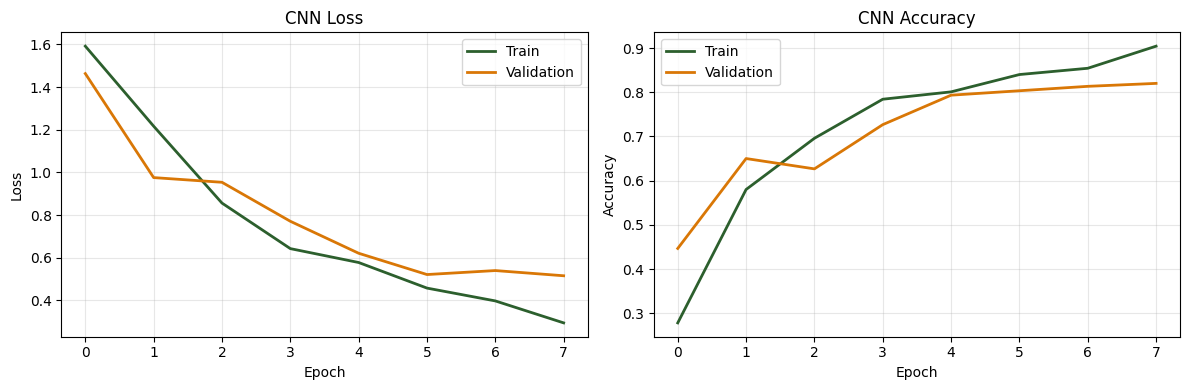

       accuracy    loss  val_accuracy  val_loss
epoch                                          
0        0.2783  1.5918        0.4467    1.4632
1        0.5800  1.2168        0.6500    0.9758
2        0.6958  0.8564        0.6267    0.9538
3        0.7842  0.6430        0.7267    0.7711
4        0.8008  0.5778        0.7933    0.6212
5        0.8400  0.4579        0.8033    0.5214
6        0.8542  0.3978        0.8133    0.5401
7        0.9042  0.2948        0.8200    0.5157


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train",      linewidth=2, color="#2C5F2D")
axes[0].plot(history.history["val_loss"], label="Validation", linewidth=2, color="#D97706")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("CNN Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"],     label="Train",      linewidth=2, color="#2C5F2D")
axes[1].plot(history.history["val_accuracy"], label="Validation", linewidth=2, color="#D97706")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-epoch table — paste this output back to me
hist_df = pd.DataFrame(history.history).round(4)
hist_df.index.name = "epoch"
print(hist_df)

In [13]:
from sklearn.metrics import classification_report

for name, info in results.items():
    print(f"\n===== {name} (acc={info['accuracy']:.4f}) =====")
    print(classification_report(
        y_test, info["predictions"],
        target_names=[n.replace("Tomato___", "") for n in label_names],
        digits=3,
    ))


===== KNN (acc=0.6140) =====
                precision    recall  f1-score   support

Bacterial_spot      0.409     0.850     0.552       100
  Early_blight      0.588     0.100     0.171       100
   Late_blight      0.810     0.470     0.595       100
     Leaf_Mold      0.835     0.760     0.796       100
       healthy      0.706     0.890     0.788       100

      accuracy                          0.614       500
     macro avg      0.670     0.614     0.580       500
  weighted avg      0.670     0.614     0.580       500


===== Logistic Regression (acc=0.7040) =====
                precision    recall  f1-score   support

Bacterial_spot      0.656     0.800     0.721       100
  Early_blight      0.478     0.430     0.453       100
   Late_blight      0.695     0.570     0.626       100
     Leaf_Mold      0.842     0.850     0.846       100
       healthy      0.829     0.870     0.849       100

      accuracy                          0.704       500
     macro avg      0.7

## 10. Compare model accuracy

This chart gives a simple comparison of how each model performed.


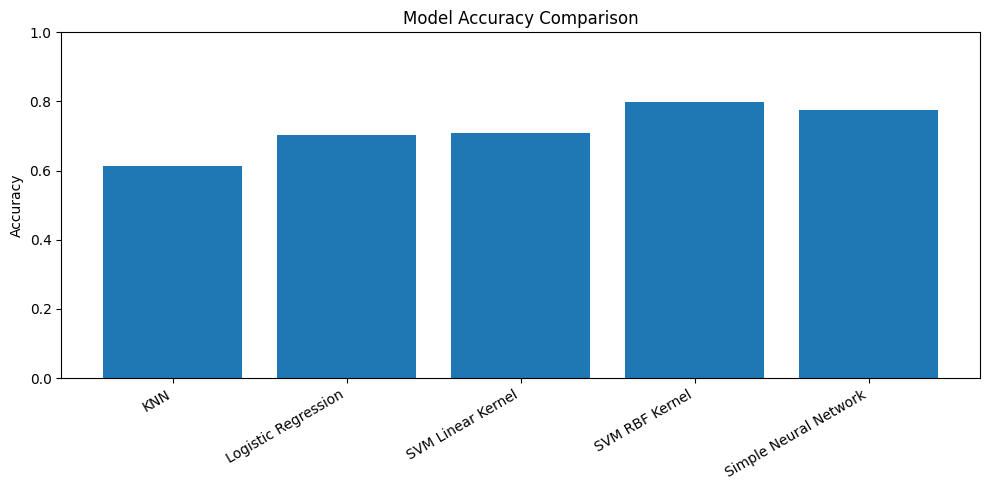

KNN: 0.6140
Logistic Regression: 0.7040
SVM Linear Kernel: 0.7080
SVM RBF Kernel: 0.7980
Simple Neural Network: 0.7740


In [14]:
model_names = list(results.keys())
accuracies = [results[name]["accuracy"] for name in model_names]

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

for name in model_names:
    print(f"{name}: {results[name]['accuracy']:.4f}")


## 11. Classification report for the best model

Accuracy is useful, but precision, recall, and F1-score give more detail about which classes the model handles well.


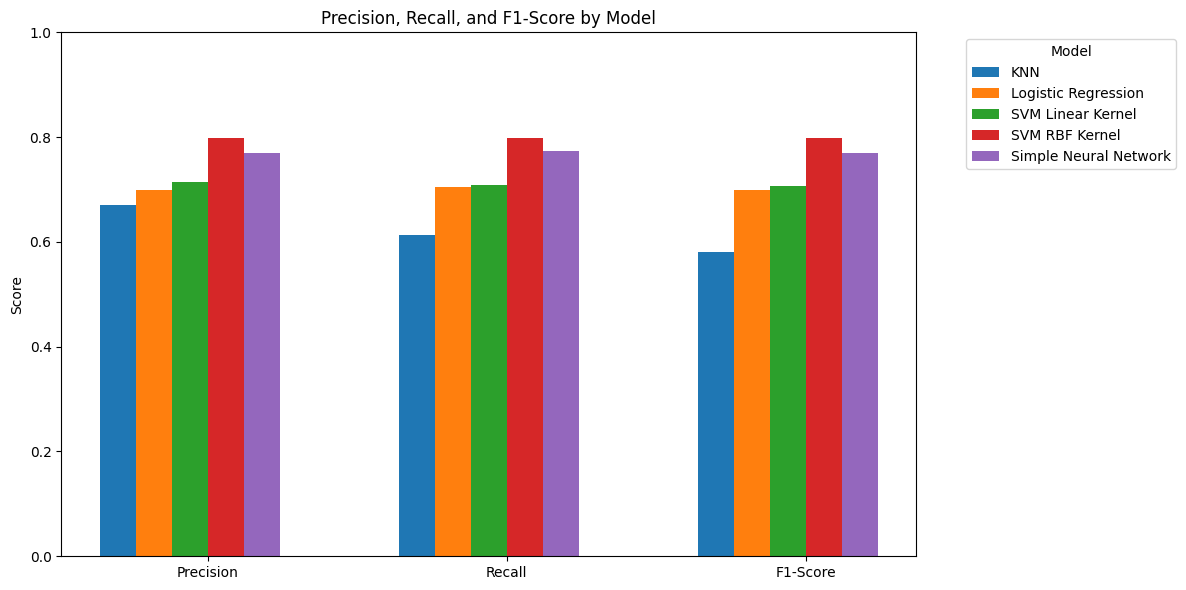

In [15]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

model_names = []

precisions = []
recalls = []
f1_scores = []

for name in results:
    preds = results[name]["predictions"]

    model_names.append(name)

    precisions.append(
        precision_score(y_test, preds, average="weighted")
    )

    recalls.append(
        recall_score(y_test, preds, average="weighted")
    )

    f1_scores.append(
        f1_score(y_test, preds, average="weighted")
    )

metrics = {
    "Precision": precisions,
    "Recall": recalls,
    "F1-Score": f1_scores
}

x = np.arange(len(metrics))
width = 0.12

plt.figure(figsize=(12, 6))

for i in range(len(model_names)):
    values = []

    for metric_name in metrics:
        values.append(metrics[metric_name][i])

    plt.bar(
        x + (i - len(model_names) / 2) * width,
        values,
        width,
        label=model_names[i]
    )

plt.xticks(x, metrics.keys())

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Precision, Recall, and F1-Score by Model")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [18]:
# Pick the best model by accuracy
best_model_name = max(results, key=lambda n: results[n]["accuracy"])
best_predictions = results[best_model_name]["predictions"]
print(f"Best model: {best_model_name} ({results[best_model_name]['accuracy']:.4f})")

# Use the matching ground truth for the best model
if best_model_name == "Basic CNN":
    y_true_for_cm = y_cnn_test
else:
    y_true_for_cm = y_test

Best model: SVM RBF Kernel (0.7980)


## 12. Confusion matrix

The confusion matrix shows which classes are being confused with each other.


<Figure size 800x800 with 0 Axes>

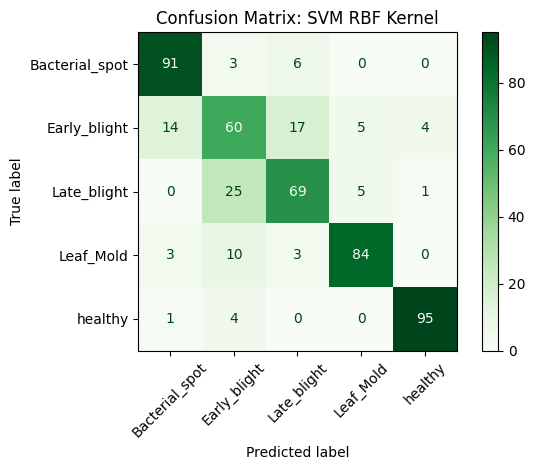


Raw confusion matrix (rows=true, cols=pred):
Labels: ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'healthy']
[[91  3  6  0  0]
 [14 60 17  5  4]
 [ 0 25 69  5  1]
 [ 3 10  3 84  0]
 [ 1  4  0  0 95]]


In [19]:
cm = confusion_matrix(y_test, best_predictions)

short_labels = [n.replace("Tomato___", "") for n in label_names]
plt.figure(figsize=(8, 8))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_labels)
display.plot(xticks_rotation=45, cmap="Greens")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRaw confusion matrix (rows=true, cols=pred):")
print("Labels:", short_labels)
print(cm)


## 13. Testing a single image


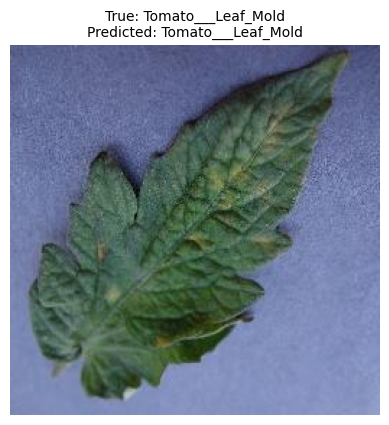

In [20]:
def predict_single_image(image_path, model, scaler, label_names):
    model_name = type(model).__name__

    if "Sequential" in model_name:
        img = Image.open(image_path).convert("RGB")
        img = img.resize((64, 64))

        img_array = np.array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)
        predicted_index = np.argmax(prediction[0])

        return label_names[predicted_index]

    else:
        features = image_to_features(image_path)

        features = np.array([features])

        features_scaled = scaler.transform(features)

        prediction = model.predict(features_scaled)[0]

        return label_names[prediction]


# Demo using a random test image
random_index = random.randint(0, len(image_paths) - 1)

sample_image_path = image_paths[random_index]

best_model = results[best_model_name]["model"]

predicted_label = predict_single_image(
    sample_image_path,
    best_model,
    scaler,
    label_names
)

true_label = label_names[y[random_index]]

img = Image.open(sample_image_path).convert("RGB")

plt.imshow(img)

plt.axis("off")

plt.title(
    f"True: {true_label}\nPredicted: {predicted_label}",
    fontsize=10
)

plt.show()

## 14. Summary

**Main topic:** Plant disease classification using classical machine learning models.

**Why it matters:** Early plant disease detection can help farmers and growers respond faster before diseases spread.

**Data source:** PlantVillage for labeled training images, plus optional scraped images from university extension websites for additional real-world examples.

**Goal:** Compare KNN, Logistic Regression, SVM, a simple neural network, and a CNN to see which model performs best using simple image features.